In [14]:
import pandas as pd
import numpy as np
import gsw
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
sns.set_context("notebook")

In [27]:
data = pd.read_csv("5906484qcno2PO4.txt",skiprows = 71, sep='\t',
    parse_dates = ['mon/day/yr'], na_values = [-10000000000.0])

data.columns

Index(['Cruise', 'Station', 'Type', 'mon/day/yr', 'hh:mm', 'Lon [°E]',
       'Lat [°N]', 'QF', 'Pressure[dbar]', 'QF.1', 'Temperature[°C]', 'QF.2',
       'Salinity[pss]', 'QF.3', 'Sigma_theta[kg/m^3]', 'QF.4', 'Depth[m]',
       'QF.5', 'Oxygen[µmol/kg]', 'QF.6', 'OxygenSat[%]', 'QF.7',
       'Nitrate[µmol/kg]', 'QF.8', 'Chl_a[mg/m^3]', 'QF.9', 'b_bp700[1/m]',
       'QF.10', 'POC[mmol/m^3]', 'QF.11', 'pHinsitu[Total]', 'QF.12',
       'pH25C[Total]', 'QF.13', 'TALK_LIAR[µmol/kg]', 'QF.14',
       'DIC_LIAR[µmol/kg]', 'QF.15', 'pCO2_LIAR[µatm]', 'QF.16',
       'Nitrite[µmol/kg]', 'QF.17', 'S2O3[µmol/kg]', 'QF.18',
       'PO4_CANY[µmol/kg]', 'QF.19', 'NO3_CANY[µmol/kg]', 'QF.20'],
      dtype='object')

In [35]:
data['QF.7'].value_counts()

0.0    4891
8.0      70
Name: QF.7, dtype: int64

In [18]:
data = pd.read_csv("5906484qcno2PO4.txt",skiprows = 71, sep='\t',
    parse_dates = ['mon/day/yr'], na_values = [-10000000000.0])

cols = {
    'Station': "station",
    'Lat [°N]': "lat",
    'Lon [°E]': "lon",
    'Pressure[dbar]': "press",
    'Temperature[°C]': "temperature",
    'QF.2':'temp_flag',
    'Salinity[pss]': "sal",
    'QF.3': "sal_flag",
    'Oxygen[µmol/kg]': "O2",
    'QF.6': "O2_flag",
    'Nitrate[µmol/kg]':"NO3",
    'QF.8':'NO3_flag',
    'Nitrite[µmol/kg]': "NO2",
    'QF.17': "NO2_flag",
    'PO4_CANY[µmol/kg]': "phosphate",
    'QF.19': "phosphate_flag",
    'pHinsitu[Total]': "pH_insitu",
    'QF.12': "pH_tot_flag",
    'TALK_LIAR[µmol/kg]':'TA',
    'QF.14':"TA_flag",
    'DIC_LIAR[µmol/kg]':'DIC',
    'QF.15':'DIC_flag'
}
data = data.rename(columns=cols)

# Select Flagged Bad Data

flag_good = np.array([0]) # 0 = good, 8 = bad
idx_flag = np.where(
    (np.isin(data["temp_flag"], flag_good))
    & (np.isin(data["sal_flag"], flag_good))
    & (np.isin(data["O2_flag"], flag_good))
    & (np.isin(data["NO3_flag"], flag_good))
    & (np.isin(data["phosphate_flag"], flag_good))
    & (np.isin(data["pH_tot_flag"], flag_good))
    & (np.isin(data["TA_flag"], flag_good))
    & (np.isin(data["NO2_flag"], flag_good))
)

# Calculate Density
SA = gsw.SA_from_SP(data["sal"], data["press"], data["lon"], data["lat"])
CT = gsw.CT_from_t(SA, data["temperature"], data["press"])
data["sigma0"] = gsw.density.sigma0(SA, CT)
data["rho"] = gsw.density.rho(SA, CT, data["press"])

data["Nstar"] = ((data.NO2 + data.NO3) - 16 * data.phosphate + 2.9)

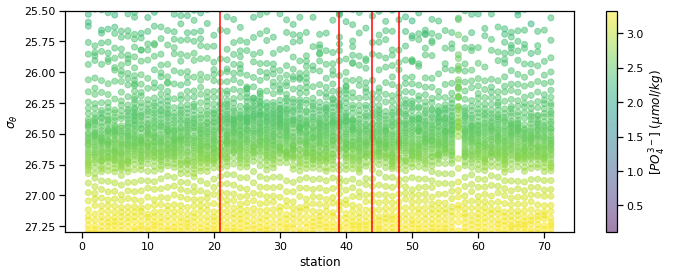

In [25]:
fig, ax = plt.subplots(1,1, figsize = (10,4))

cax = ax.scatter(data['station'],
           data['sigma0'],
            #data['Depth[m]'],
                 alpha = 0.5,
           c = data["phosphate"])
cbar = fig.colorbar(cax).set_label('$[PO_4^{3-}]\ (\mu mol/kg$)')
#cax.set_clim([0,4.0])

ax.set_ylim([27.3,25.5])
#ax.set_ylim([2000,0])

ax.axvline(21, color = "r")
ax.axvline(39, color = "r")
ax.axvline(44, color = "r")
ax.axvline(48, color = "r")

ax.set_xlabel("station")
ax.set_ylabel(r"$\sigma_{\theta}$")
plt.tight_layout()
plt.savefig("figures/no2section.pdf")

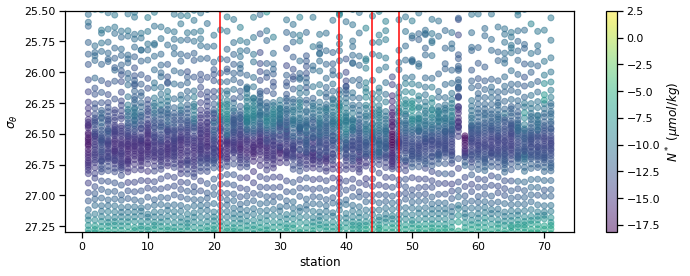

In [26]:
fig, ax = plt.subplots(1,1, figsize = (10,4))

cax = ax.scatter(data['station'],
           data['sigma0'],
            #data['Depth[m]'],
                 alpha = 0.5,
           c = data["Nstar"])
cbar = fig.colorbar(cax).set_label('$N^*\ (\mu mol/kg$)')
#cax.set_clim([0,4.0])

ax.set_ylim([27.3,25.5])
#ax.set_ylim([2000,0])

ax.axvline(21, color = "r")
ax.axvline(39, color = "r")
ax.axvline(44, color = "r")
ax.axvline(48, color = "r")

ax.set_xlabel("station")
ax.set_ylabel(r"$\sigma_{\theta}$")
plt.tight_layout()
plt.savefig("figures/no2section.pdf")

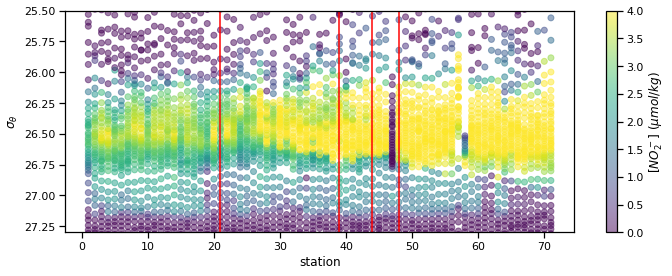

In [23]:
fig, ax = plt.subplots(1,1, figsize = (10,4))

cax = ax.scatter(data['station'],
           data['sigma0'],
            #data['Depth[m]'],
                 alpha = 0.5,
           c = data['NO2'])
cbar = fig.colorbar(cax).set_label('$[NO_2^-]\ (\mu mol/kg$)')
cax.set_clim([0,4.0])

ax.set_ylim([27.3,25.5])
#ax.set_ylim([2000,0])

ax.axvline(21, color = "r")
ax.axvline(39, color = "r")
ax.axvline(44, color = "r")
ax.axvline(48, color = "r")

ax.set_xlabel("station")
ax.set_ylabel(r"$\sigma_{\theta}$")
plt.tight_layout()
plt.savefig("figures/no2section.pdf")

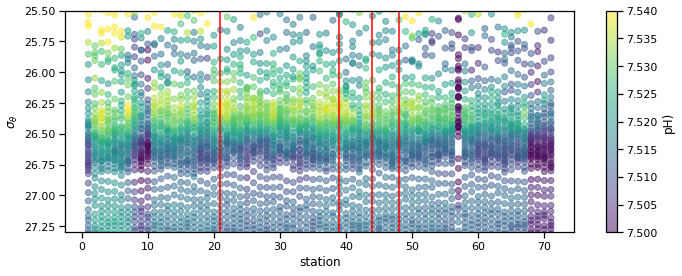

In [22]:
fig, ax = plt.subplots(1,1, figsize = (10,4))

cax = ax.scatter(data['station'],
           data['sigma0'],
            #data['Depth[m]'],
                 alpha = 0.5,
           c = data['pH_insitu'])
cbar = fig.colorbar(cax).set_label('pH)')
cax.set_clim([7.5,7.54])

ax.set_ylim([27.3,25.5])
#ax.set_ylim([2000,0])

ax.axvline(21, color = "r")
ax.axvline(39, color = "r")
ax.axvline(44, color = "r")
ax.axvline(48, color = "r")

ax.set_xlabel("station")
ax.set_ylabel(r"$\sigma_{\theta}$")
plt.tight_layout()
plt.savefig("figures/pHsection.pdf")

/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_79301/3761498143.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(1,1, figsize = (3,4))


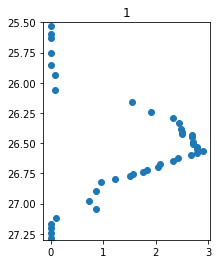

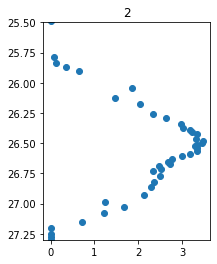

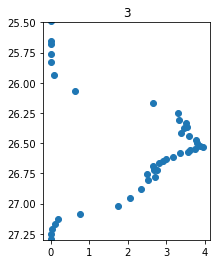

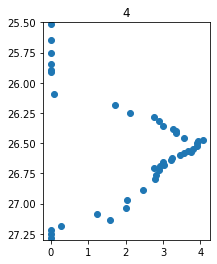

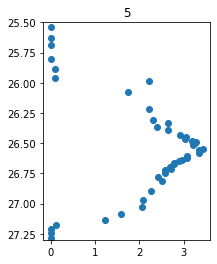

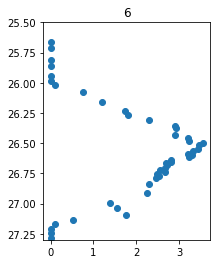

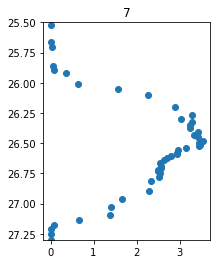

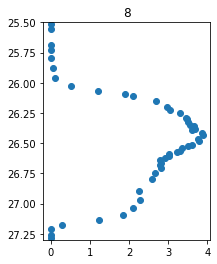

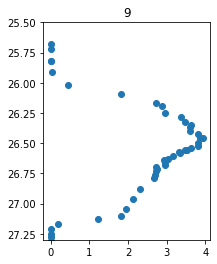

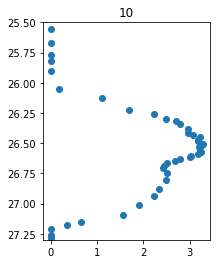

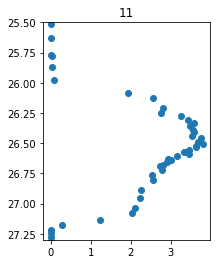

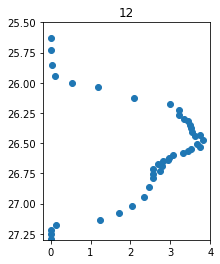

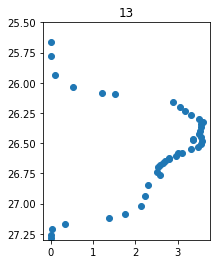

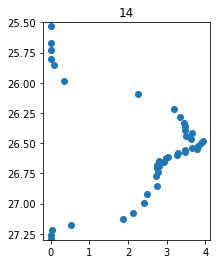

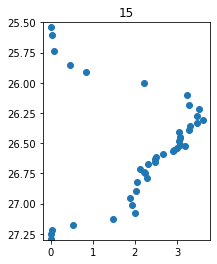

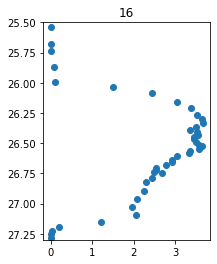

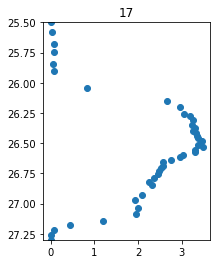

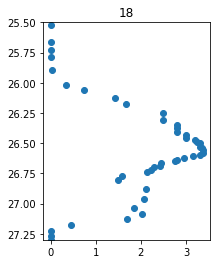

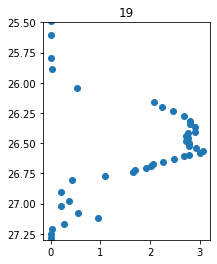

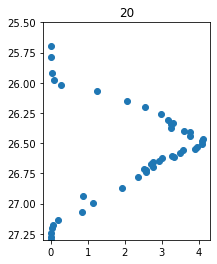

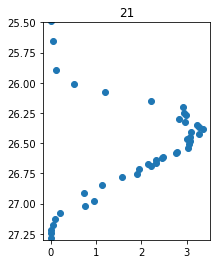

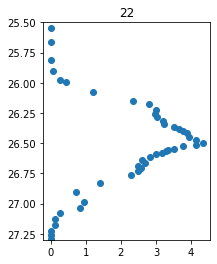

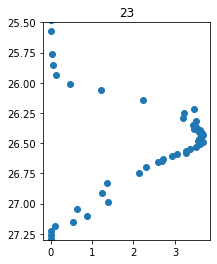

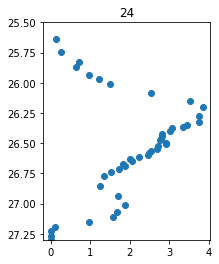

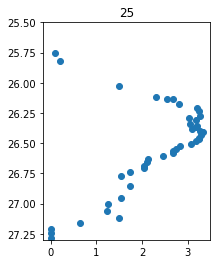

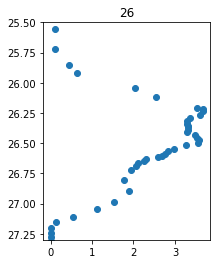

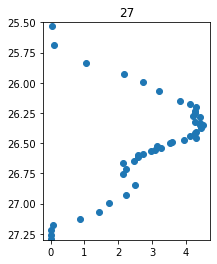

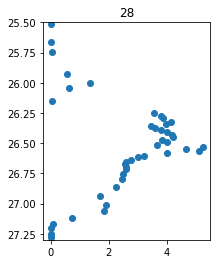

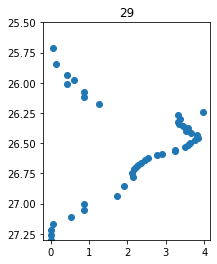

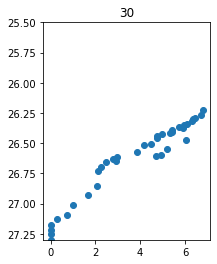

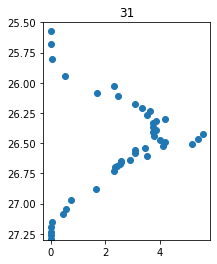

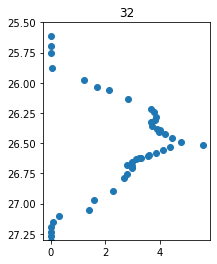

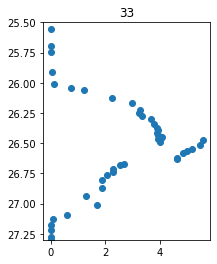

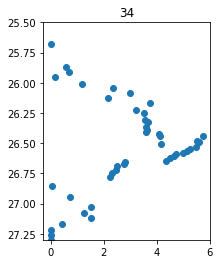

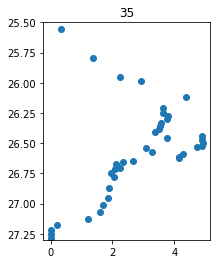

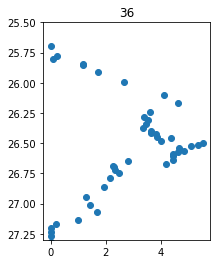

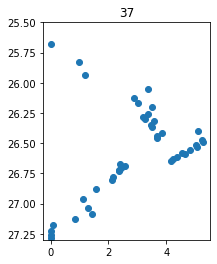

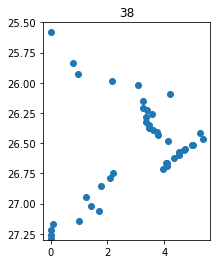

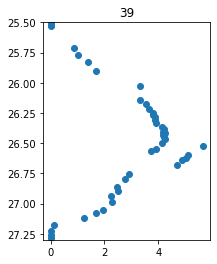

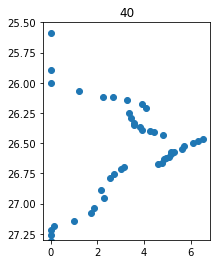

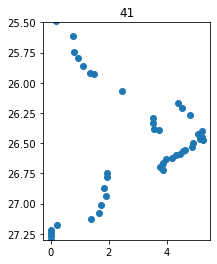

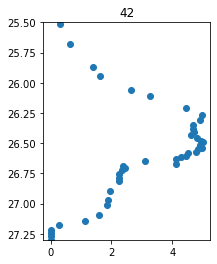

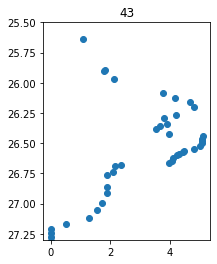

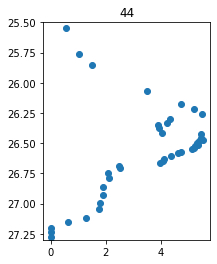

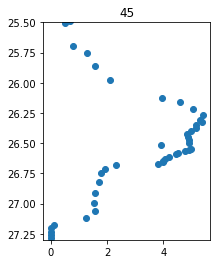

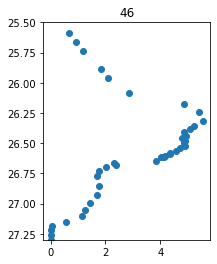

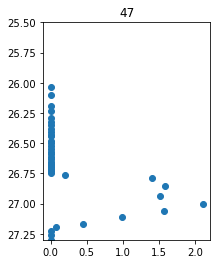

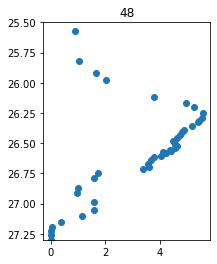

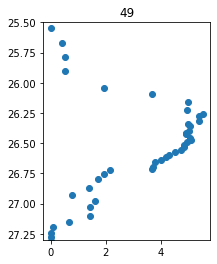

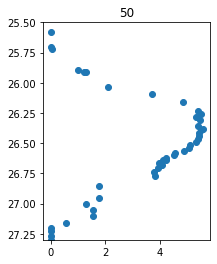

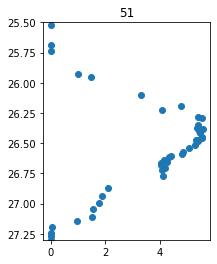

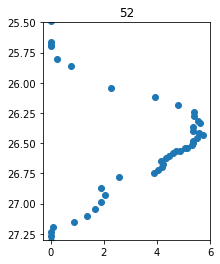

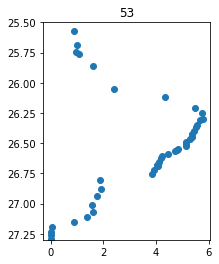

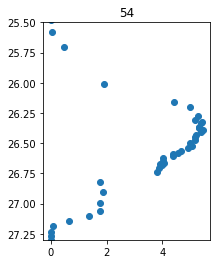

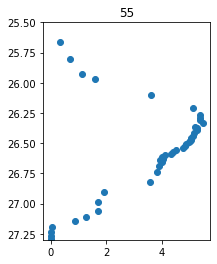

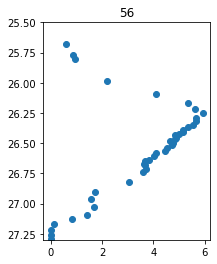

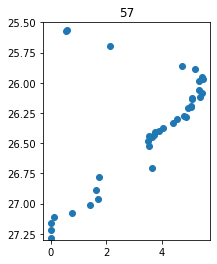

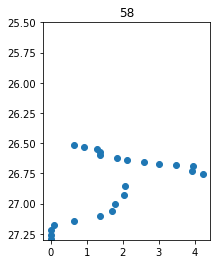

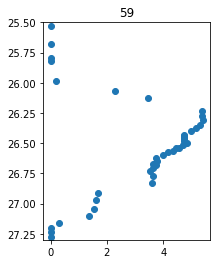

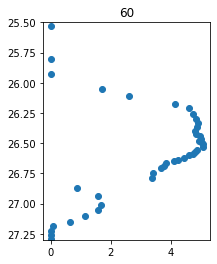

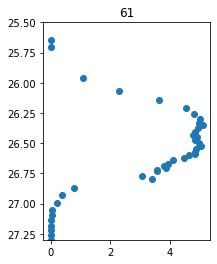

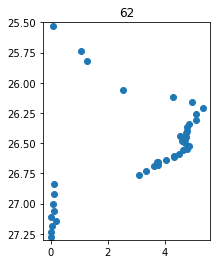

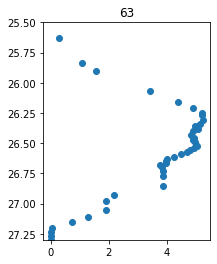

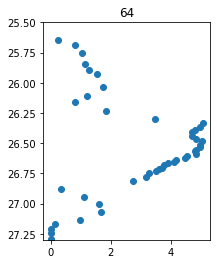

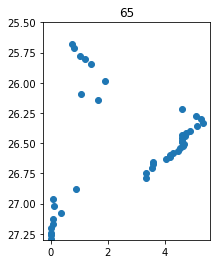

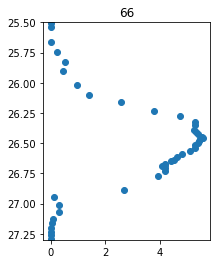

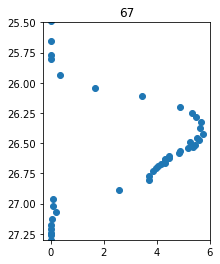

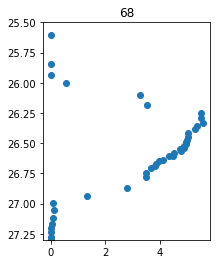

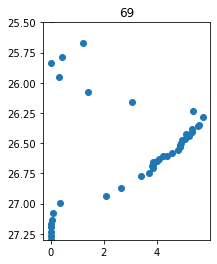

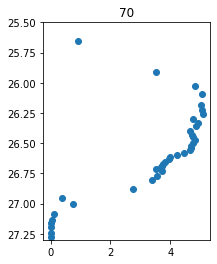

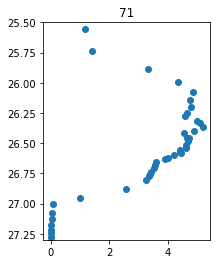

In [13]:
for s in data['station'].drop_duplicates():
    temp = data[data['station']==s]
    fig, ax = plt.subplots(1,1, figsize = (3,4))
    ax.scatter(temp.NO2,
               temp['sigma0']
              )
    ax.set_ylim([27.3,25.5])
    ax.set_title(f"{s}")

In [3]:
f5906484 = pd.read_csv("5906484qcno2.txt",skiprows = 70, sep='\t',
    parse_dates = ['mon/day/yr'], na_values = [-10000000000.0])
# add 'month' column so we can match gridded WOA data
f5906484['month'] = f5906484['mon/day/yr'].dt.strftime('%m')
f5906484['month'] = f5906484['month'].astype(int)
f5906484 =  f5906484[ f5906484['Nitrite[µmol/kg]'] > 0] # why are we doing this?

data = f5906484

data['depth'] = customround(data['Depth[m]'])
data['lon'] = round(data['Lon [°E]']) + 0.5 #round_off(data['Lon [°E]'])
data['lon'] = data['lon'] - 360.0
data['lat'] = round(data['Lat [°N]']) + 0.5 #round_off(data['Lat [°N]'])


def process_WOA(month):
    if i<10:
        link = f'https://www.ncei.noaa.gov/thredds-ocean/dodsC/ncei/woa/phosphate/all/1.00/woa18_all_p0{month}_01.nc'
    elif i>=10:
        link = f'https://www.ncei.noaa.gov/thredds-ocean/dodsC/ncei/woa/phosphate/all/1.00/woa18_all_p{month}_01.nc'
    ds = xr.open_dataset(link, decode_times = False)
    ds = ds.sel(lat = slice(16,19),lon = slice(-110, -106))
    df = ds.to_dataframe(dim_order = ['lat', 'nbounds', 'lon', 'depth', 'time'])
    df = df.reset_index().set_index('depth')
    indexdf = pd.DataFrame(np.arange(0,805,5), columns = ['depth']).set_index('depth')
    monthlydf = pd.DataFrame([])
    for lat in df.lat.drop_duplicates():
        for lon in df.lon.drop_duplicates():
            subset = df[(df.lat == lat) & (df.lon ==lon)]
            temp = indexdf.join(subset)
            temp = temp.ffill(axis=0)
            temp['lat'] = lat
            temp['lon'] = lon
            monthlydf = pd.concat([monthlydf, temp])
    monthlydf = monthlydf.reset_index()
    monthlydf = monthlydf[['lat','lon','depth','p_an']].groupby(['lat','lon','depth']).mean()
    monthlydf['month'] = month
    return monthlydf

data = data.set_index(['month','lat','lon','depth'])

WOA = pd.DataFrame()

for i in range(1,13):
    print(i)
    monthlyWOA = process_WOA(i)
    WOA = pd.concat([WOA, monthlyWOA])

WOA = WOA.reset_index()
WOA = WOA.set_index(['month','lat','lon','depth'])

data = data.join(WOA)
print(data['p_an'].head())

1
2
3
4
5
6
7
8
9
10
11
12
month  lat   lon     depth
1      17.5  -107.5  110.0    2.116911
                     120.0    2.116911
                     130.0    2.412905
                     140.0    2.412905
                     150.0    2.505203
Name: p_an, dtype: float32
